# Notebook 1: Frame Extraction

This notebook extracts frames from the 21 plant videos provided in the  dataset Folder. Each video becomes one class folder (`class1` ... `class21`), containing all extracted frames from that video.

This project:
- Computes brightness and lighting category per frame (saved later in metadata)
- Actually deletes near-duplicate frames (not just print them)

**Inputs:** folder of 21 raw video files (.mp4)
**Outputs:** folder of 21 class subfolders, each containing extracted JPG frames


## 1.1 Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
from pathlib import Path
import shutil


VIDEO_FOLDER = Path('/content/drive/MyDrive/Dataset')
OUTPUT_FOLDER = Path('/content/drive/MyDrive/VisionProject/Extracted_Images')


# Settings
TARGET_FPS = 2         # Extract 2 frames per second from each video
BLUR_THRESHOLD = 30    # Reject frames blurrier than this (Laplacian variance)
DEDUP_THRESHOLD = 0.92 # Reject frames more similar than this to the previous frame
JPEG_QUALITY = 90

print("Video folder:", VIDEO_FOLDER)
print("Output folder:", OUTPUT_FOLDER)
print(f"Settings: {TARGET_FPS} fps, blur threshold {BLUR_THRESHOLD}, dedup at {DEDUP_THRESHOLD}")

Video folder: /content/drive/MyDrive/Dataset
Output folder: /content/drive/MyDrive/VisionProject/Extracted_Images
Settings: 2 fps, blur threshold 30, dedup at 0.92


## 1.2 Helper Functions

In [3]:
def compute_blur_score(image_gray):
    """Higher = sharper. Below ~30 typically indicates blur."""
    return cv2.Laplacian(image_gray, cv2.CV_64F).var()


def frames_similar(frame_a, frame_b, threshold=0.92):
    """Returns True if two frames are too similar (near-duplicates).
    Uses zero-mean normalized cross-correlation on downsampled versions."""
    a_small = cv2.resize(frame_a, (128, 72))
    b_small = cv2.resize(frame_b, (128, 72))
    a_gray = cv2.cvtColor(a_small, cv2.COLOR_BGR2GRAY).astype(np.float32)
    b_gray = cv2.cvtColor(b_small, cv2.COLOR_BGR2GRAY).astype(np.float32)
    a_norm = (a_gray - a_gray.mean()) / (a_gray.std() + 1e-8)
    b_norm = (b_gray - b_gray.mean()) / (b_gray.std() + 1e-8)
    corr = np.sum(a_norm * b_norm) / a_norm.size
    return corr > threshold


def extract_from_video(video_path, output_dir, class_label):
    """Extract quality-filtered, deduplicated frames from one video."""
    output_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"  ERROR: could not open {video_path.name}")
        return 0

    video_fps = cap.get(cv2.CAP_PROP_FPS) or 30
    sample_every = max(1, int(round(video_fps / TARGET_FPS)))

    frame_idx = 0
    saved = 0
    rejected_blur = 0
    rejected_dup = 0
    prev_kept = None

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % sample_every != 0:
            frame_idx += 1
            continue

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur_score = compute_blur_score(gray)

        if blur_score < BLUR_THRESHOLD:
            rejected_blur += 1
            frame_idx += 1
            continue

        if prev_kept is not None and frames_similar(frame, prev_kept, DEDUP_THRESHOLD):
            rejected_dup += 1
            frame_idx += 1
            continue

        out_name = f"{class_label}_frame_{saved:04d}.jpg"
        cv2.imwrite(str(output_dir / out_name), frame, [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])
        prev_kept = frame.copy()
        saved += 1
        frame_idx += 1

    cap.release()
    print(f"  {class_label}: kept {saved}, rejected {rejected_blur} blurry, {rejected_dup} duplicates")
    return saved

## 1.3 Extract Frames From All 21 Videos

In [4]:
# output folder
if OUTPUT_FOLDER.exists():
    shutil.rmtree(OUTPUT_FOLDER)
OUTPUT_FOLDER.mkdir(parents=True)


VIDEO_FOLDER = Path('/content/drive/MyDrive/Dataset')

video_exts = {".mp4", ".avi", ".mov", ".mkv", ".3gp", ".wmv", ".m4v"}
videos = [] # Initialize as empty

if not VIDEO_FOLDER.exists():
    print(f"ERROR: The specified VIDEO_FOLDER '{VIDEO_FOLDER}' does not exist.")

else:
    # Find all videos in consistent order
    videos = sorted(p for p in VIDEO_FOLDER.iterdir() if p.suffix.lower() in video_exts)

print(f"Found {len(videos)} videos\n")

total_frames = 0
if videos: # Only proceed if videos were found
    for i, video_path in enumerate(videos, start=1):
        class_label = f"class{i}"
        class_dir = OUTPUT_FOLDER / class_label
        print(f"[{i}/{len(videos)}] {video_path.name}")
        saved = extract_from_video(video_path, class_dir, class_label)
        total_frames += saved
else:
    print("No videos to process. Please correct the VIDEO_FOLDER path.")

print(f"\nTotal frames extracted across all classes: {total_frames}")

Found 21 videos

[1/21] VID_20260408_171126.mp4
  class1: kept 23, rejected 10 blurry, 0 duplicates
[2/21] VID_20260408_171454.mp4
  class2: kept 23, rejected 10 blurry, 0 duplicates
[3/21] VID_20260408_171606.mp4
  class3: kept 34, rejected 0 blurry, 0 duplicates
[4/21] VID_20260408_171903.mp4
  class4: kept 37, rejected 0 blurry, 0 duplicates
[5/21] VID_20260408_172029.mp4
  class5: kept 37, rejected 0 blurry, 0 duplicates
[6/21] VID_20260408_172233.mp4
  class6: kept 31, rejected 0 blurry, 0 duplicates
[7/21] VID_20260408_172556.mp4
  class7: kept 50, rejected 0 blurry, 0 duplicates
[8/21] VID_20260408_172740.mp4
  class8: kept 34, rejected 4 blurry, 0 duplicates
[9/21] VID_20260408_172835.mp4
  class9: kept 23, rejected 0 blurry, 0 duplicates
[10/21] VID_20260408_172918.mp4
  class10: kept 34, rejected 1 blurry, 0 duplicates
[11/21] VID_20260408_173112.mp4
  class11: kept 37, rejected 16 blurry, 0 duplicates
[12/21] VID_20260408_173310.mp4
  class12: kept 37, rejected 3 blurry, 0 d

## 1.4 Verify Extraction

In [5]:
# Show frame count per class
from collections import OrderedDict

counts = OrderedDict()
for cls_dir in sorted(OUTPUT_FOLDER.iterdir()):
    if cls_dir.is_dir():
        counts[cls_dir.name] = len(list(cls_dir.glob("*.jpg")))

print(f"{'Class':<12} {'Frames':>8}")
print("-" * 22)
for cls, n in counts.items():
    print(f"{cls:<12} {n:>8}")
print("-" * 22)
print(f"{'TOTAL':<12} {sum(counts.values()):>8}")
print(f"\nMin: {min(counts.values())}  Max: {max(counts.values())}  Ratio: {max(counts.values())/min(counts.values()):.1f}x")

Class          Frames
----------------------
class1             23
class10            34
class11            37
class12            37
class13            48
class14            62
class15            26
class16             4
class17            56
class18            33
class19            14
class2             23
class20            23
class21            33
class3             34
class4             37
class5             37
class6             31
class7             50
class8             34
class9             23
----------------------
TOTAL             699

Min: 4  Max: 62  Ratio: 15.5x


## 1.5 Preview A Sample Frame

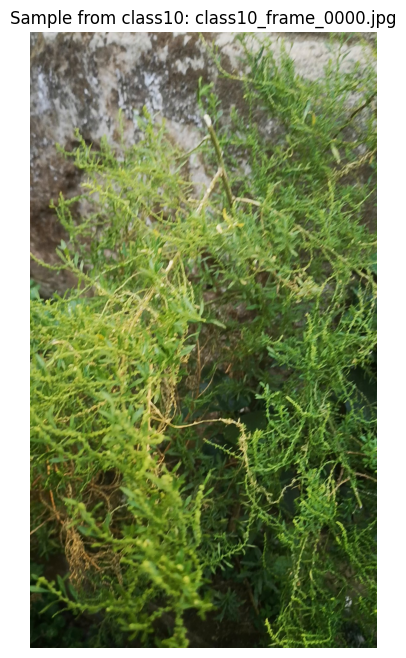

In [6]:
import matplotlib.pyplot as plt

sample_class = list(counts.keys())[1]
sample_dir = OUTPUT_FOLDER / sample_class
sample_files = sorted(sample_dir.glob("*.jpg"))
if sample_files:
    img = cv2.cvtColor(cv2.imread(str(sample_files[0])), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 8))
    plt.imshow(img)
    plt.title(f"Sample from {sample_class}: {sample_files[0].name}")
    plt.axis("off")
    plt.show()
else:
    print("No samples found.")


**Next step:** Running Notebook 2 for Preprocessing to resize frames, split into train/val/test, and compute lighting metadata.